### **Sentiment Analysis with LSTM**  

This notebook focuses on training and evaluating a Long Short-Term Memory (LSTM) model for sentiment analysis using three datasets: Amazon Books Reviews, Sentiment140, and Yelp Reviews. The goal is to leverage deep learning techniques, particularly Bidirectional LSTM (BiLSTM) and attention mechanisms, to improve sentiment classification performance.  

The workflow includes data loading, text preprocessing, model training, hyperparameter optimization, and evaluation. Additionally, augmented datasets are used to test model robustness against noisy input. The notebook implements both*standard BiLSTM and BiLSTM with attention to compare their effectiveness in handling sentiment analysis tasks.  

#### **1. LSTM Model - Amazon Books Reviews**  
- **1.1. Loading Data**  
- **1.2. Data Preprocessing**  
- **1.3. Model Training**  
- **1.4. Searching for Best Model Parameters**  
  - **1.4.1. BiLSTM**  
  - **1.4.2. BiLSTM + Attention**  
- **1.5. Model Evaluation on Test Data**  
- **1.6. Model Evaluation on Augmented Data**  
- **1.7. Save Model**  

#### **2. LSTM Model - Sentiment140**  
- **2.1. Loading Data**  
- **2.2. Data Preprocessing**  
- **2.3. Model Training**  
- **2.4. Searching for Best Model Parameters**  
  - **2.4.1. BiLSTM**  
  - **2.4.2. BiLSTM + Attention**  
- **2.5. Model Evaluation on Test Data**  
- **2.6. Model Evaluation on Augmented Data**  
- **2.7. Save Model**  

#### **3. LSTM Model - Yelp Reviews**  
- **3.1. Loading Data**  
- **3.2. Data Preprocessing**  
- **3.3. Model Training**  
- **3.4. Searching for Best Model Parameters**  
  - **3.4.1. BiLSTM**  
  - **3.4.2. BiLSTM + Attention**  
- **3.5. Model Evaluation on Test Data**  
- **3.6. Model Evaluation on Augmented Data**  
- **3.7. Save Model**  


In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import tensorflow as tf
from tensorflow.keras.models import Sequential, Model
from tensorflow.keras.layers import Embedding, LSTM, Dense, Dropout, Bidirectional, Attention, Input, Softmax, Multiply, Lambda
from tensorflow.keras.regularizers import l2
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.callbacks import EarlyStopping
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report
from nltk.stem import WordNetLemmatizer

In [2]:
import os
import sys

src_path = os.path.abspath('../src')
sys.path.append(src_path)

from preprocessing.data_utils import DataUtils
from models import train_lstm

In [3]:
models_output_dir = '../outputs/models/lstm'

In [4]:
import fasttext
import fasttext.util

# define the model file path
model_path = "../data/embeddings/cc.en.300.bin"

# download the FastText model if it does not exist
if not os.path.exists(model_path):
    fasttext.util.download_model('en', if_exists='ignore')  # download English FastText model (300D)

# load the FastText model
fasttext_model = fasttext.load_model(model_path)

In [5]:
# preprocess and tokenize data
def preprocess_data(df, max_length=128, vocab_size=10000):
    # initialize tokenizer and lemmatizer
    tokenizer = Tokenizer(num_words=vocab_size, oov_token="<OOV>")
    lemmatizer = WordNetLemmatizer()

    # remove missing or empty values
    df = df.dropna(subset=['Review']).copy()
    df = df[df['Review'].str.strip() != '']

    # extract texts and labels
    texts = df['Review'].astype(str).tolist()
    labels = df['Polarity'].values

    # apply lemmatization
    texts = [" ".join([lemmatizer.lemmatize(word) for word in text.split()]) for text in texts]

    # tokenize and pad sequences
    tokenizer.fit_on_texts(texts)
    sequences = tokenizer.texts_to_sequences(texts)
    padded_sequences = pad_sequences(sequences, maxlen=max_length, padding='post', truncating='post')

    return padded_sequences, np.array(labels), tokenizer

In [6]:
# preprocess and tokenize data using existing tokenizer
def tokenize_with_existing_tokenizer(df, tokenizer, max_length):
    texts = df['Review'].astype(str).tolist()
    sequences = tokenizer.texts_to_sequences(texts)
    padded_sequences = pad_sequences(sequences, maxlen=max_length, padding='post', truncating='post')
    labels = df['Polarity'].values
    return padded_sequences, labels

In [7]:
def attention_layer(inputs):
    attention_weights = Dense(1, activation="tanh")(inputs)  # compute attention weights
    attention_weights = Softmax(axis=1)(attention_weights)  # normalize weights to [0,1]
    context_vector = Multiply()([inputs, attention_weights])  # multiply input by attention weights
    context_vector = Lambda(lambda x: tf.reduce_sum(x, axis=1))(context_vector)  # sum over the sequence
    return context_vector

# 1. LSTM Model - Amazon Books Reviews

## 1.1. Loading Data

In [8]:
# load the dataset
amazon_file = '../data/preprocessed/amazon.csv'
amazon_df = pd.read_csv(amazon_file, engine='python', encoding="ISO-8859-1")

In [9]:
# preview the data
amazon_df.head()

,Polarity,Review
0,0,As a Man Stinketh
1,1,MY FAVORITE!!
2,1,Epic novel
3,1,Very good source for Web Applications Development
4,1,Great fantasy


In [10]:
train_val_amazon_df, test_amazon_df = train_test_split(
    amazon_df, 
    test_size=0.15, 
    random_state=42, 
    stratify=amazon_df['Polarity']
)

In [11]:
train_amazon_df, val_amazon_df = train_test_split(
    train_val_amazon_df, 
    test_size=0.1765, # 15% of the original data
    random_state=42, 
    stratify=train_val_amazon_df['Polarity']
)

In [12]:
DataUtils.count_reviews_by_polarity(train_amazon_df)

Number of reviews with Polarity=1: 49382
Number of reviews with Polarity=0: 49382


In [13]:
DataUtils.count_reviews_by_polarity(val_amazon_df)

Number of reviews with Polarity=1: 10585
Number of reviews with Polarity=0: 10584


In [14]:
DataUtils.count_reviews_by_polarity(test_amazon_df)

Number of reviews with Polarity=1: 10582
Number of reviews with Polarity=0: 10583


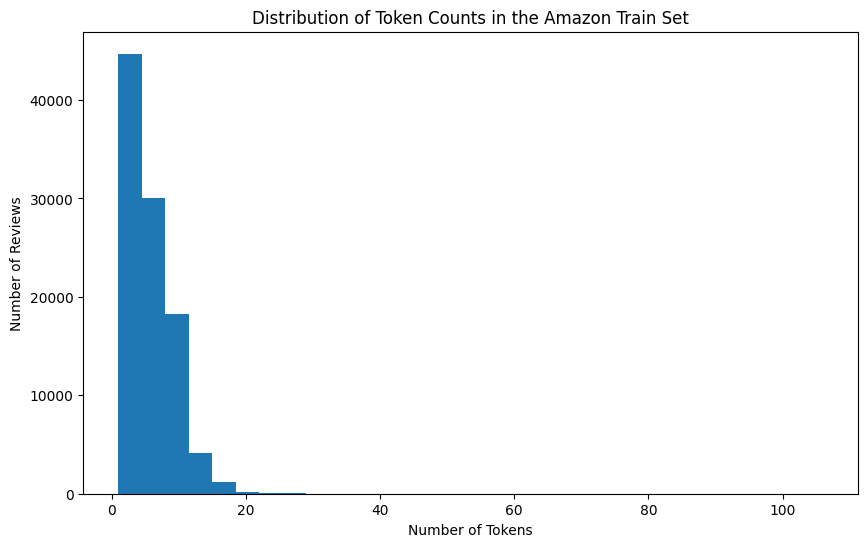

In [15]:
DataUtils.plot_token_distribution(train_amazon_df, "Amazon Train Set")

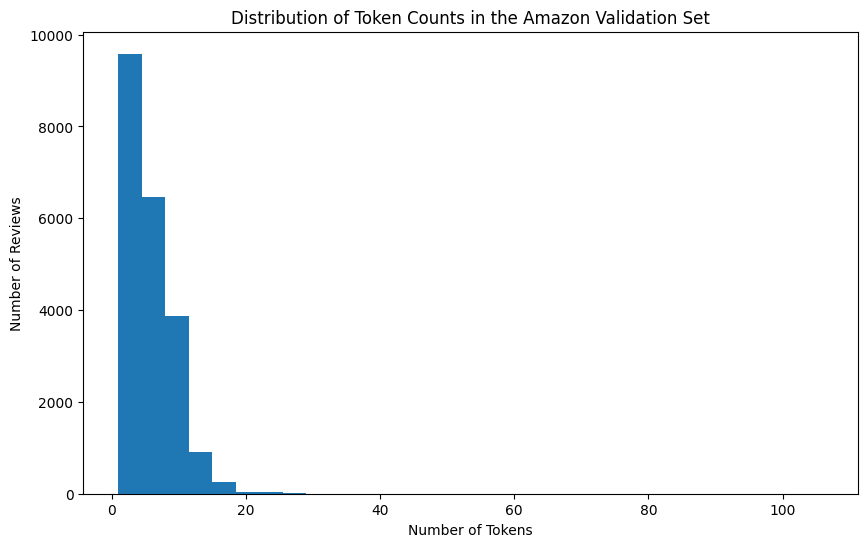

In [16]:
DataUtils.plot_token_distribution(val_amazon_df, "Amazon Validation Set")

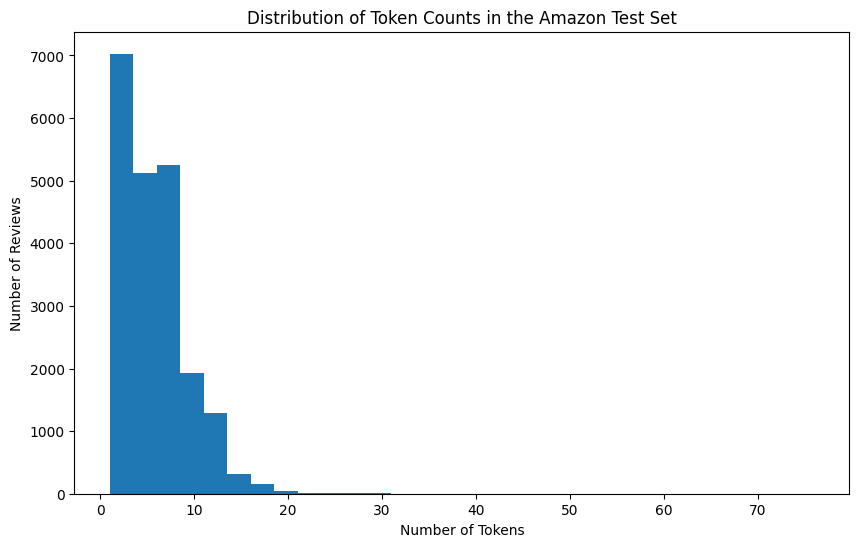

In [17]:
DataUtils.plot_token_distribution(test_amazon_df, "Amazon Test Set")

## 1.2. Data Preprocessing

In [150]:
# set preprocessing parameters
vocab_size = 12000  # maximum number of words in the tokenizer
max_length = 32  # maximum length of input sequences

In [151]:
# preprocess train data and fit tokenizer
X_train, y_train, tokenizer = preprocess_data(train_amazon_df, max_length=max_length, vocab_size=vocab_size)

In [152]:
# preprocess val data 
X_val, y_val = tokenize_with_existing_tokenizer(val_amazon_df, tokenizer, max_length)

In [153]:
# preprocess test data
X_test, y_test = tokenize_with_existing_tokenizer(test_amazon_df, tokenizer, max_length)

## 1.3. Model Training

In [174]:
# set model parameters
batch_size = 32
epochs = 10
learning_rate = 0.001

In [175]:
# set embedding parameters
embedding_dim = 300  # dimension of word vectors
embedding_matrix = np.zeros((vocab_size, embedding_dim)) 

for word, i in tokenizer.word_index.items():
    if i < vocab_size:  
        embedding_matrix[i] = fasttext_model.get_word_vector(word)  

print("Embedding matrix created with shape:", embedding_matrix.shape)

Embedding matrix created with shape: (12000, 300)


In [176]:
# define model architecture
model_lstm = Sequential([
    Embedding(input_dim=vocab_size, output_dim=embedding_dim, 
              input_length=max_length, weights=[embedding_matrix], 
              trainable=False),
    LSTM(64, return_sequences=False),
    Dropout(0.3),
    Dense(32, activation='relu'),
    Dropout(0.3),
    Dense(1, activation='sigmoid')  
])

In [177]:
model_lstm.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=learning_rate),
              loss='binary_crossentropy',
              metrics=['accuracy'])

In [195]:
model_lstm.summary()

Model: "sequential_15"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 embedding_19 (Embedding)    (None, 32, 300)           3600000   
                                                                 
 lstm_32 (LSTM)              (None, 64)                93440     
                                                                 
 dropout_51 (Dropout)        (None, 64)                0         
                                                                 
 dense_45 (Dense)            (None, 32)                2080      
                                                                 
 dropout_52 (Dropout)        (None, 32)                0         
                                                                 
 dense_46 (Dense)            (None, 1)                 33        
                                                                 
Total params: 3,695,553
Trainable params: 95,553
Non-

In [178]:
# define callbacks
early_stopping = EarlyStopping(
    monitor='val_loss',
    patience=2,
    restore_best_weights=True
)

In [179]:
# train the model
history_lstm = model_lstm.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=epochs,
    batch_size=batch_size,
    callbacks=[early_stopping]
)

Epoch 1/10
3087/3087 [==============================] - 28s 9ms/step - loss: 0.4529 - accuracy: 0.7878 - val_loss: 0.4107 - val_accuracy: 0.8041
Epoch 2/10
3087/3087 [==============================] - 26s 9ms/step - loss: 0.4004 - accuracy: 0.8118 - val_loss: 0.4105 - val_accuracy: 0.8067
Epoch 3/10
3087/3087 [==============================] - 27s 9ms/step - loss: 0.3826 - accuracy: 0.8215 - val_loss: 0.3808 - val_accuracy: 0.8178
Epoch 4/10
3087/3087 [==============================] - 27s 9ms/step - loss: 0.3675 - accuracy: 0.8291 - val_loss: 0.3750 - val_accuracy: 0.8267
Epoch 5/10
3087/3087 [==============================] - 27s 9ms/step - loss: 0.3546 - accuracy: 0.8365 - val_loss: 0.3735 - val_accuracy: 0.8297
Epoch 6/10
3087/3087 [==============================] - 27s 9ms/step - loss: 0.3451 - accuracy: 0.8438 - val_loss: 0.3601 - val_accuracy: 0.8329
Epoch 7/10
3087/3087 [==============================] - 27s 9ms/step - loss: 0.3355 - accuracy: 0.8470 - val_loss: 0.3592 - val_ac

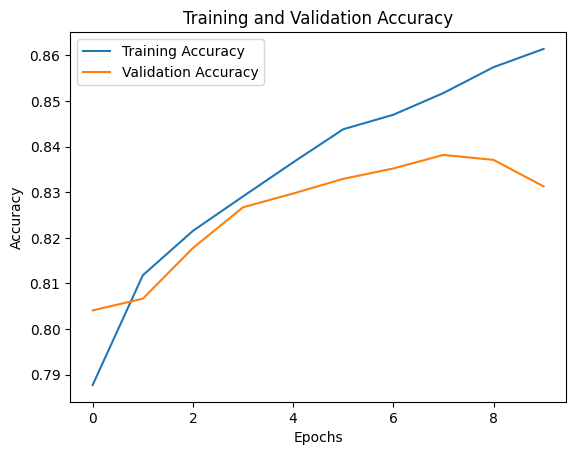

In [180]:
# plot accuracy on training and validation data
plt.plot(history_lstm.history['accuracy'], label='Training Accuracy')
plt.plot(history_lstm.history['val_accuracy'], label='Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.title('Training and Validation Accuracy')
plt.show()

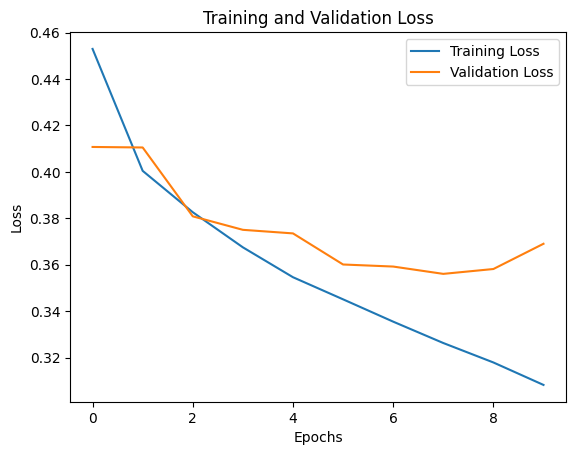

In [181]:
# plot loss on training and validation data
plt.plot(history_lstm.history['loss'], label='Training Loss')
plt.plot(history_lstm.history['val_loss'], label='Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.title('Training and Validation Loss')
plt.show()

In [182]:
# evaluate the model on the validation set
print("\nValidation Results:")
y_val_pred = (model_lstm.predict(X_val) > 0.5).astype(int).flatten()
print(classification_report(y_val, y_val_pred))


Validation Results:
662/662 [==============================] - 2s 2ms/step
              precision    recall  f1-score   support

           0       0.84      0.83      0.84     10584
           1       0.84      0.84      0.84     10585

    accuracy                           0.84     21169
   macro avg       0.84      0.84      0.84     21169
weighted avg       0.84      0.84      0.84     21169



## 1.4. Searching for Best Model Parameters

### 1.4.1. BiLSTM

In [183]:

model_bilstm = Sequential([
    Embedding(input_dim=vocab_size, output_dim=embedding_dim, 
              input_length=max_length, weights=[embedding_matrix], 
              trainable=False),
    Bidirectional(LSTM(64, return_sequences=False)),
    Dropout(0.3),
    Dense(32, activation='relu'),
    Dropout(0.3),
    Dense(1, activation='sigmoid')  
])

In [184]:
model_bilstm.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=learning_rate),
              loss='binary_crossentropy',
              metrics=['accuracy'])

In [196]:
model_bilstm.summary()

Model: "sequential_16"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 embedding_20 (Embedding)    (None, 32, 300)           3600000   
                                                                 
 bidirectional_25 (Bidirecti  (None, 128)              186880    
 onal)                                                           
                                                                 
 dropout_53 (Dropout)        (None, 128)               0         
                                                                 
 dense_47 (Dense)            (None, 32)                4128      
                                                                 
 dropout_54 (Dropout)        (None, 32)                0         
                                                                 
 dense_48 (Dense)            (None, 1)                 33        
                                                     

In [185]:
# train the model
history_bilstm = model_bilstm.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=epochs,
    batch_size=batch_size,
    callbacks=[early_stopping]
)

Epoch 1/10
3087/3087 [==============================] - 36s 11ms/step - loss: 0.4357 - accuracy: 0.7923 - val_loss: 0.4006 - val_accuracy: 0.8088
Epoch 2/10
3087/3087 [==============================] - 33s 11ms/step - loss: 0.3860 - accuracy: 0.8186 - val_loss: 0.3816 - val_accuracy: 0.8184
Epoch 3/10
3087/3087 [==============================] - 31s 10ms/step - loss: 0.3692 - accuracy: 0.8281 - val_loss: 0.3789 - val_accuracy: 0.8189
Epoch 4/10
3087/3087 [==============================] - 31s 10ms/step - loss: 0.3555 - accuracy: 0.8360 - val_loss: 0.3702 - val_accuracy: 0.8259
Epoch 5/10
3087/3087 [==============================] - 31s 10ms/step - loss: 0.3451 - accuracy: 0.8403 - val_loss: 0.3604 - val_accuracy: 0.8316
Epoch 6/10
3087/3087 [==============================] - 31s 10ms/step - loss: 0.3349 - accuracy: 0.8456 - val_loss: 0.3584 - val_accuracy: 0.8329
Epoch 7/10
3087/3087 [==============================] - 30s 10ms/step - loss: 0.3271 - accuracy: 0.8506 - val_loss: 0.3610 -

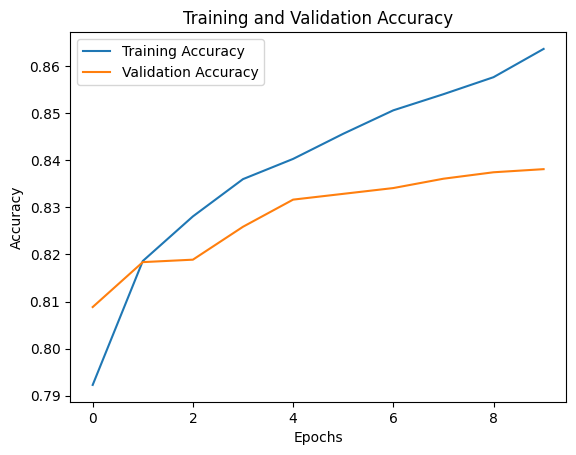

In [186]:
# plot accuracy on training and validation data
plt.plot(history_bilstm.history['accuracy'], label='Training Accuracy')
plt.plot(history_bilstm.history['val_accuracy'], label='Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.title('Training and Validation Accuracy')
plt.show()

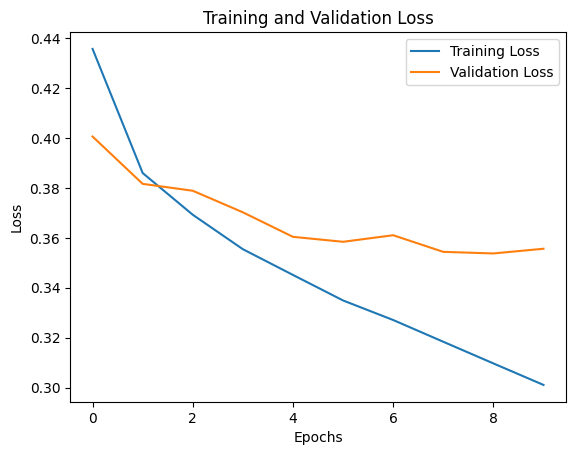

In [187]:
# plot loss on training and validation data
plt.plot(history_bilstm.history['loss'], label='Training Loss')
plt.plot(history_bilstm.history['val_loss'], label='Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.title('Training and Validation Loss')
plt.show()

In [188]:
# evaluate the model on the validation set
print("\nValidation Results:")
y_val_pred = (model_bilstm.predict(X_val) > 0.5).astype(int).flatten()
print(classification_report(y_val, y_val_pred))


Validation Results:
662/662 [==============================] - 3s 3ms/step
              precision    recall  f1-score   support

           0       0.84      0.83      0.84     10584
           1       0.83      0.85      0.84     10585

    accuracy                           0.84     21169
   macro avg       0.84      0.84      0.84     21169
weighted avg       0.84      0.84      0.84     21169



### 1.4.2. BiLSTM + Attention

In [189]:
def build_attention_lstm_model_amazon(vocab_size, embedding_dim, max_length, embedding_matrix, learning_rate=0.001):
    # define inputs
    inputs = Input(shape=(max_length,))
    
    # embedding layer
    embedding = Embedding(input_dim=vocab_size, output_dim=embedding_dim, 
                          input_length=max_length, weights=[embedding_matrix], 
                          trainable=False)(inputs)

    # BiLSTM layer
    lstm_output = Bidirectional(LSTM(64, return_sequences=True))(embedding)  

    # attention layer
    attention_output = attention_layer(lstm_output)

    # fully connected layers
    dropout1 = Dropout(0.3)(attention_output)
    dense1 = Dense(32, activation='relu')(dropout1)
    dropout2 = Dropout(0.3)(dense1)
    outputs = Dense(1, activation='sigmoid')(dropout2)

    # define the model
    model = Model(inputs=inputs, outputs=outputs)

    # compile the model
    model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=learning_rate), 
                  loss='binary_crossentropy', metrics=['accuracy'])

    return model

In [190]:
model_attention = build_attention_lstm_model_amazon(vocab_size=vocab_size, embedding_dim=embedding_dim, max_length=max_length, embedding_matrix=embedding_matrix, learning_rate=learning_rate)

In [197]:
model_attention.summary()

Model: "model_4"
__________________________________________________________________________________________________
 Layer (type)                   Output Shape         Param #     Connected to                     
 input_5 (InputLayer)           [(None, 32)]         0           []                               
                                                                                                  
 embedding_21 (Embedding)       (None, 32, 300)      3600000     ['input_5[0][0]']                
                                                                                                  
 bidirectional_26 (Bidirectiona  (None, 32, 128)     186880      ['embedding_21[0][0]']           
 l)                                                                                               
                                                                                                  
 dense_49 (Dense)               (None, 32, 1)        129         ['bidirectional_26[0][0]'] 

In [191]:
# train the model
history_attention = model_attention.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=epochs,
    batch_size=batch_size,
    callbacks=[early_stopping]
)

Epoch 1/10
3087/3087 [==============================] - 43s 13ms/step - loss: 0.4399 - accuracy: 0.7899 - val_loss: 0.4059 - val_accuracy: 0.8013
Epoch 2/10
3087/3087 [==============================] - 38s 12ms/step - loss: 0.3959 - accuracy: 0.8117 - val_loss: 0.3931 - val_accuracy: 0.8116
Epoch 3/10
3087/3087 [==============================] - 37s 12ms/step - loss: 0.3771 - accuracy: 0.8230 - val_loss: 0.3836 - val_accuracy: 0.8139
Epoch 4/10
3087/3087 [==============================] - 37s 12ms/step - loss: 0.3619 - accuracy: 0.8319 - val_loss: 0.3824 - val_accuracy: 0.8204
Epoch 5/10
3087/3087 [==============================] - 37s 12ms/step - loss: 0.3502 - accuracy: 0.8367 - val_loss: 0.3659 - val_accuracy: 0.8288
Epoch 6/10
3087/3087 [==============================] - 37s 12ms/step - loss: 0.3389 - accuracy: 0.8436 - val_loss: 0.3607 - val_accuracy: 0.8298
Epoch 7/10
3087/3087 [==============================] - 37s 12ms/step - loss: 0.3275 - accuracy: 0.8494 - val_loss: 0.3568 -

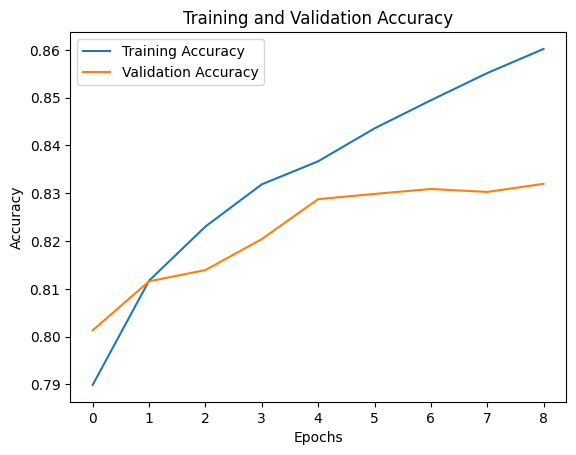

In [192]:
# plot accuracy on training and validation data
plt.plot(history_attention.history['accuracy'], label='Training Accuracy')
plt.plot(history_attention.history['val_accuracy'], label='Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.title('Training and Validation Accuracy')
plt.show()

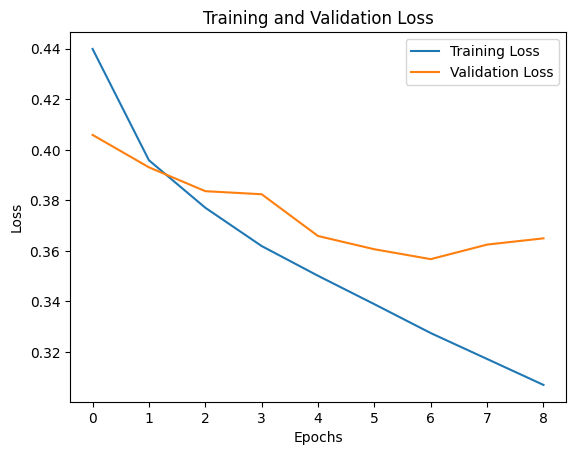

In [193]:
# plot loss on training and validation data
plt.plot(history_attention.history['loss'], label='Training Loss')
plt.plot(history_attention.history['val_loss'], label='Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.title('Training and Validation Loss')
plt.show()

In [194]:
# evaluate the model on the validation set
print("\nValidation Results:")
y_val_pred = (model_attention.predict(X_val) > 0.5).astype(int).flatten()
print(classification_report(y_val, y_val_pred))


Validation Results:
662/662 [==============================] - 5s 5ms/step
              precision    recall  f1-score   support

           0       0.86      0.79      0.82     10584
           1       0.81      0.87      0.84     10585

    accuracy                           0.83     21169
   macro avg       0.83      0.83      0.83     21169
weighted avg       0.83      0.83      0.83     21169



## 1.5. Model Evaluation on Test Data

In [198]:
train_lstm.evaluate_model(model=model_bilstm, tokenizer=tokenizer, test_df=test_amazon_df, max_length=max_length)

662/662 [==============================] - 2s 4ms/step

Classification Report for Test Set:

              precision    recall  f1-score   support

           0       0.84      0.83      0.84     10583
           1       0.84      0.84      0.84     10582

    accuracy                           0.84     21165
   macro avg       0.84      0.84      0.84     21165
weighted avg       0.84      0.84      0.84     21165



## 1.6. Model Evaluation on Augmented Data

In [199]:
# load the augmented test sets
test_amazon_char_swap_file = '../data/preprocessed/amazon_test_char_swap.csv'
test_amazon_char_swap_df = pd.read_csv(test_amazon_char_swap_file, engine='python', encoding="ISO-8859-1")

test_amazon_embedding_file = '../data/preprocessed/amazon_test_embedding.csv'
test_amazon_embedding_df = pd.read_csv(test_amazon_embedding_file, engine='python', encoding="ISO-8859-1")

test_amazon_eda_file = '../data/preprocessed/amazon_test_eda.csv'
test_amazon_eda_df = pd.read_csv(test_amazon_eda_file, engine='python', encoding="ISO-8859-1")

In [200]:
train_lstm.evaluate_model(model=model_bilstm, tokenizer=tokenizer, test_df=test_amazon_char_swap_df, max_length=max_length)

662/662 [==============================] - 2s 3ms/step

Classification Report for Test Set:

              precision    recall  f1-score   support

           0       0.77      0.72      0.75     10583
           1       0.74      0.78      0.76     10582

    accuracy                           0.75     21165
   macro avg       0.75      0.75      0.75     21165
weighted avg       0.75      0.75      0.75     21165



In [201]:
train_lstm.evaluate_model(model=model_bilstm, tokenizer=tokenizer, test_df=test_amazon_embedding_df, max_length=max_length)


662/662 [==============================] - 2s 3ms/step

Classification Report for Test Set:

              precision    recall  f1-score   support

           0       0.80      0.77      0.78     10583
           1       0.78      0.81      0.79     10582

    accuracy                           0.79     21165
   macro avg       0.79      0.79      0.79     21165
weighted avg       0.79      0.79      0.79     21165



In [202]:
train_lstm.evaluate_model(model=model_bilstm, tokenizer=tokenizer, test_df=test_amazon_eda_df, max_length=max_length)


662/662 [==============================] - 2s 3ms/step

Classification Report for Test Set:

              precision    recall  f1-score   support

           0       0.80      0.80      0.80     10583
           1       0.80      0.80      0.80     10582

    accuracy                           0.80     21165
   macro avg       0.80      0.80      0.80     21165
weighted avg       0.80      0.80      0.80     21165



## 1.7. Save Model

In [203]:
model_path = os.path.join(models_output_dir, "amazon_lstm_model.keras")
model_bilstm.save(model_path)

# 2. LSTM Model - Sentiment140

## 2.1. Loading Data

In [18]:
# load the dataset
sentiment140_file = '../data/preprocessed/sentiment140.csv'
sentiment140_df = pd.read_csv(sentiment140_file, engine='python', encoding="ISO-8859-1")

In [19]:
# preview the data
sentiment140_df.head()

,Polarity,Review
0,1,@Alicia_86 srry u get my tweet?
1,1,@jchiarelli TTS to take text Tweets to the pho...
2,1,Mmmm apple cinnomin oatmeal
3,1,@willwallaceii thanks man. the truth can be fu...
4,1,RAIN The plants and trees are happy ^~^


In [20]:
train_val_sentiment140_df, test_sentiment140_df = train_test_split(
    sentiment140_df, 
    test_size=0.15, 
    random_state=42, 
    stratify=sentiment140_df['Polarity']
)

In [21]:
train_sentiment140_df, val_sentiment140_df = train_test_split(
    train_val_sentiment140_df, 
    test_size=0.1765, # 15% of the original data
    random_state=42, 
    stratify=train_val_sentiment140_df['Polarity']
)

In [22]:
DataUtils.count_reviews_by_polarity(train_sentiment140_df)

Number of reviews with Polarity=1: 111996
Number of reviews with Polarity=0: 111996


In [23]:
DataUtils.count_reviews_by_polarity(val_sentiment140_df)

Number of reviews with Polarity=1: 24004
Number of reviews with Polarity=0: 24004


In [24]:
DataUtils.count_reviews_by_polarity(test_sentiment140_df)

Number of reviews with Polarity=1: 24000
Number of reviews with Polarity=0: 24000


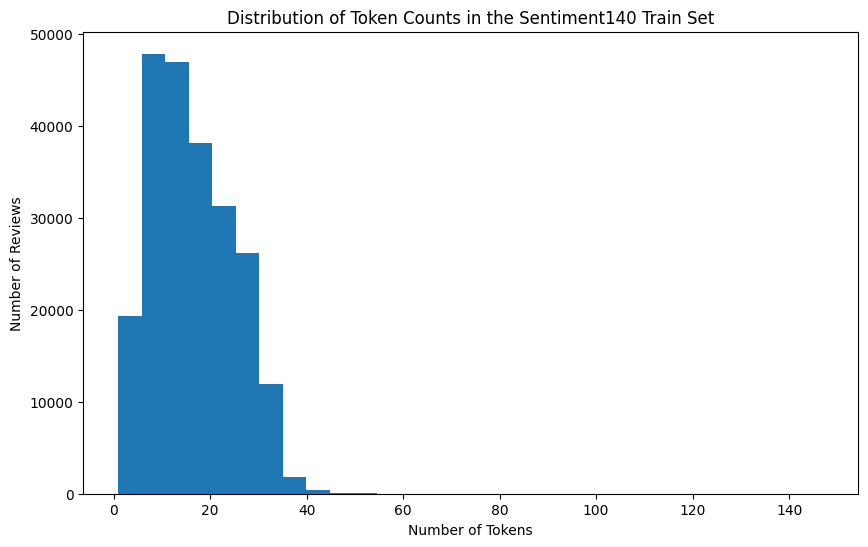

In [25]:
DataUtils.plot_token_distribution(train_sentiment140_df, "Sentiment140 Train Set")

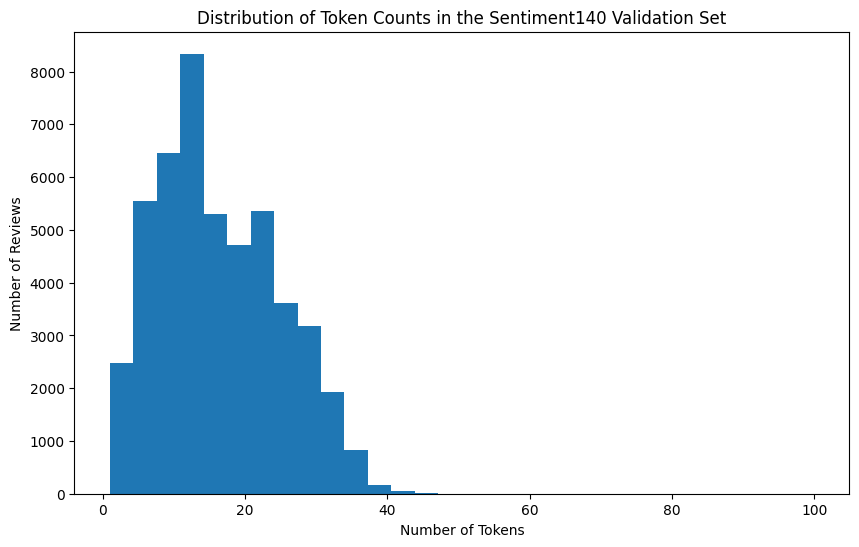

In [26]:
DataUtils.plot_token_distribution(val_sentiment140_df, "Sentiment140 Validation Set")

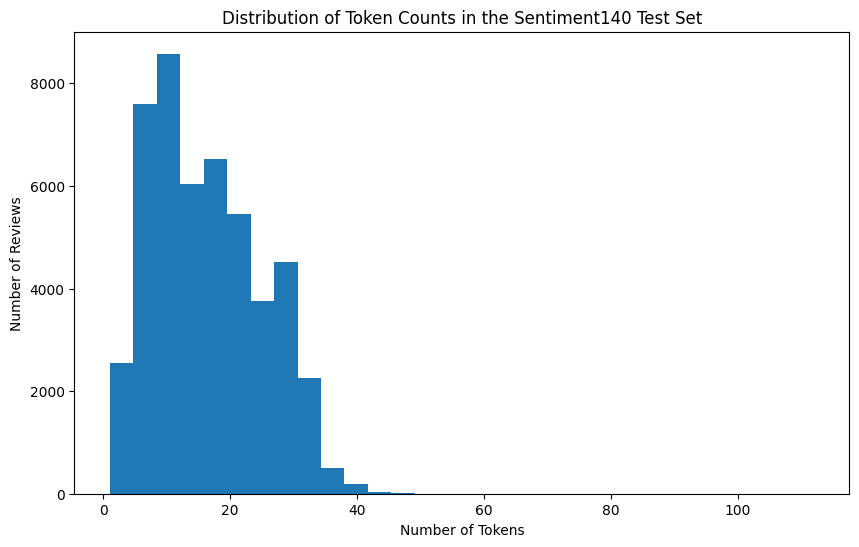

In [27]:
DataUtils.plot_token_distribution(test_sentiment140_df, "Sentiment140 Test Set")

## 2.2. Data Preprocessing

In [214]:
# set preprocessing parameters
vocab_size = 12000  # maximum number of words in the tokenizer
max_length = 64  # maximum length of input sequences

In [215]:
# preprocess train data and fit tokenizer
X_train, y_train, tokenizer = preprocess_data(train_sentiment140_df, max_length=max_length, vocab_size=vocab_size)

In [216]:
# preprocess val data 
X_val, y_val = tokenize_with_existing_tokenizer(val_sentiment140_df, tokenizer, max_length)

In [217]:
# preprocess test data
X_test, y_test = tokenize_with_existing_tokenizer(test_sentiment140_df, tokenizer, max_length)

## 2.3. Model Training

In [218]:
# set model parameters
batch_size = 32
epochs = 10
learning_rate = 0.001

In [219]:
# set embedding parameters
embedding_dim = 300  # dimension of word vectors
embedding_matrix = np.zeros((vocab_size, embedding_dim)) 

for word, i in tokenizer.word_index.items():
    if i < vocab_size:  
        embedding_matrix[i] = fasttext_model.get_word_vector(word)  

print("Embedding matrix created with shape:", embedding_matrix.shape)

Embedding matrix created with shape: (12000, 300)


In [220]:
# define model architecture
model_lstm = Sequential([
    Embedding(input_dim=vocab_size, output_dim=embedding_dim, 
              input_length=max_length, weights=[embedding_matrix], 
              trainable=False),
    LSTM(128, return_sequences=False),
    Dropout(0.3),
    Dense(64, activation='relu'),
    Dropout(0.3),
    Dense(1, activation='sigmoid')  
])

In [221]:
model_lstm.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=learning_rate),
              loss='binary_crossentropy',
              metrics=['accuracy'])

In [226]:
model_lstm.summary()

Model: "sequential_17"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 embedding_22 (Embedding)    (None, 64, 300)           3600000   
                                                                 
 lstm_35 (LSTM)              (None, 128)               219648    
                                                                 
 dropout_57 (Dropout)        (None, 128)               0         
                                                                 
 dense_52 (Dense)            (None, 64)                8256      
                                                                 
 dropout_58 (Dropout)        (None, 64)                0         
                                                                 
 dense_53 (Dense)            (None, 1)                 65        
                                                                 
Total params: 3,827,969
Trainable params: 227,969
Non

In [222]:
# define callbacks
early_stopping = EarlyStopping(
    monitor='val_loss',
    patience=2,
    restore_best_weights=True
)

In [223]:
# train the model
history_lstm = model_lstm.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=epochs,
    batch_size=batch_size,
    callbacks=[early_stopping]
)

Epoch 1/10
7000/7000 [==============================] - 67s 9ms/step - loss: 0.6933 - accuracy: 0.5036 - val_loss: 0.6929 - val_accuracy: 0.5045
Epoch 2/10
7000/7000 [==============================] - 60s 9ms/step - loss: 0.6931 - accuracy: 0.5036 - val_loss: 0.6931 - val_accuracy: 0.5000
Epoch 3/10
7000/7000 [==============================] - 58s 8ms/step - loss: 0.6932 - accuracy: 0.5006 - val_loss: 0.6933 - val_accuracy: 0.5000


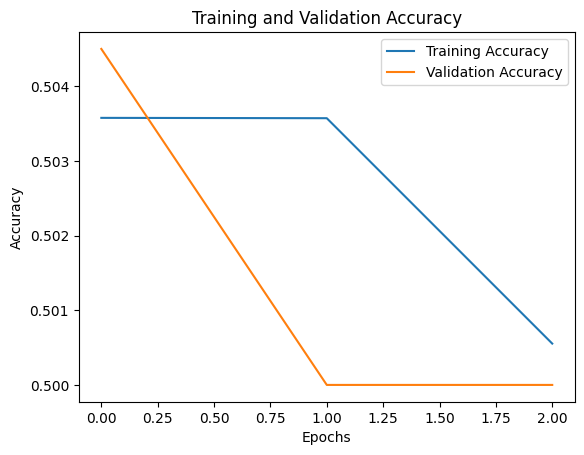

In [224]:
# plot accuracy on training and validation data
plt.plot(history_lstm.history['accuracy'], label='Training Accuracy')
plt.plot(history_lstm.history['val_accuracy'], label='Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.title('Training and Validation Accuracy')
plt.show()

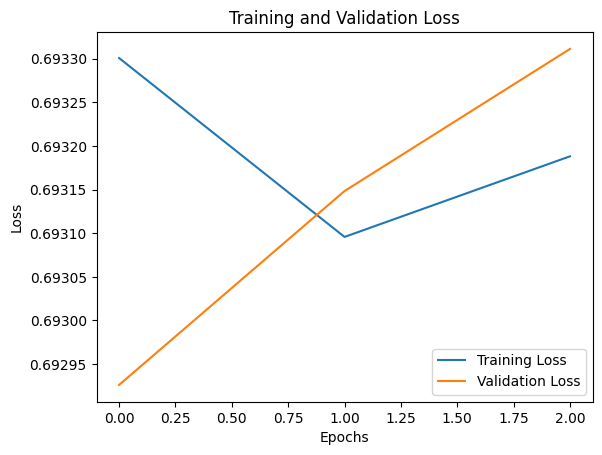

In [225]:
# plot loss on training and validation data
plt.plot(history_lstm.history['loss'], label='Training Loss')
plt.plot(history_lstm.history['val_loss'], label='Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.title('Training and Validation Loss')
plt.show()

In [227]:
# evaluate the model on the validation set
print("\nValidation Results:")
y_val_pred = (model_lstm.predict(X_val) > 0.5).astype(int).flatten()
print(classification_report(y_val, y_val_pred))


Validation Results:
1501/1501 [==============================] - 5s 3ms/step
              precision    recall  f1-score   support

           0       0.72      0.01      0.03     24004
           1       0.50      0.99      0.67     24004

    accuracy                           0.50     48008
   macro avg       0.61      0.50      0.35     48008
weighted avg       0.61      0.50      0.35     48008



## 2.4. Searching for Best Model Parameters

### 2.4.1. BiLSTM

In [228]:

model_bilstm = Sequential([
    Embedding(input_dim=vocab_size, output_dim=embedding_dim, 
              input_length=max_length, weights=[embedding_matrix], 
              trainable=False),
    Bidirectional(LSTM(128, return_sequences=False)),
    Dropout(0.3),
    Dense(64, activation='relu'),
    Dropout(0.3),
    Dense(1, activation='sigmoid')  
])

In [229]:
model_bilstm.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=learning_rate),
              loss='binary_crossentropy',
              metrics=['accuracy'])

In [230]:
model_bilstm.summary()

Model: "sequential_18"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 embedding_23 (Embedding)    (None, 64, 300)           3600000   
                                                                 
 bidirectional_27 (Bidirecti  (None, 256)              439296    
 onal)                                                           
                                                                 
 dropout_59 (Dropout)        (None, 256)               0         
                                                                 
 dense_54 (Dense)            (None, 64)                16448     
                                                                 
 dropout_60 (Dropout)        (None, 64)                0         
                                                                 
 dense_55 (Dense)            (None, 1)                 65        
                                                     

In [231]:
# train the model
history_bilstm = model_bilstm.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=epochs,
    batch_size=batch_size,
    callbacks=[early_stopping]
)

Epoch 1/10
7000/7000 [==============================] - 93s 13ms/step - loss: 0.4795 - accuracy: 0.7707 - val_loss: 0.4408 - val_accuracy: 0.7941
Epoch 2/10
7000/7000 [==============================] - 90s 13ms/step - loss: 0.4308 - accuracy: 0.8005 - val_loss: 0.4196 - val_accuracy: 0.8062
Epoch 3/10
7000/7000 [==============================] - 88s 13ms/step - loss: 0.4110 - accuracy: 0.8116 - val_loss: 0.4220 - val_accuracy: 0.8099
Epoch 4/10
7000/7000 [==============================] - 83s 12ms/step - loss: 0.3954 - accuracy: 0.8200 - val_loss: 0.4140 - val_accuracy: 0.8081
Epoch 5/10
7000/7000 [==============================] - 83s 12ms/step - loss: 0.3818 - accuracy: 0.8270 - val_loss: 0.4060 - val_accuracy: 0.8152
Epoch 6/10
7000/7000 [==============================] - 84s 12ms/step - loss: 0.3705 - accuracy: 0.8327 - val_loss: 0.4095 - val_accuracy: 0.8136
Epoch 7/10
7000/7000 [==============================] - 83s 12ms/step - loss: 0.3546 - accuracy: 0.8409 - val_loss: 0.4169 -

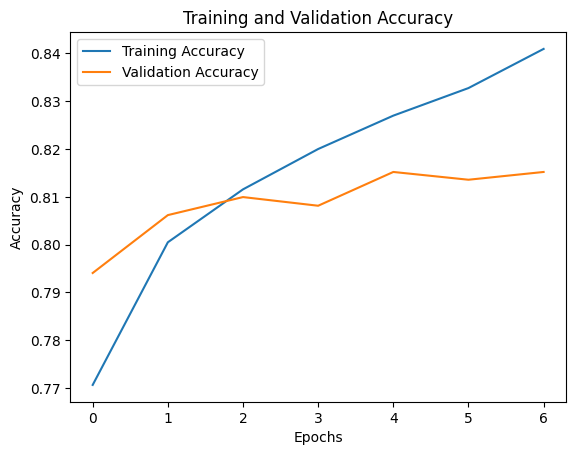

In [232]:
# plot accuracy on training and validation data
plt.plot(history_bilstm.history['accuracy'], label='Training Accuracy')
plt.plot(history_bilstm.history['val_accuracy'], label='Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.title('Training and Validation Accuracy')
plt.show()

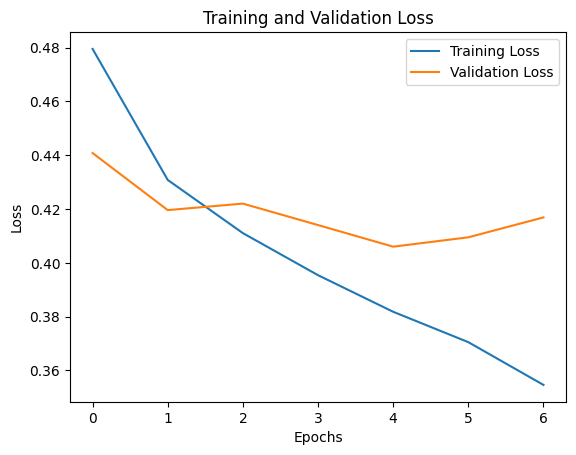

In [233]:
# plot loss on training and validation data
plt.plot(history_bilstm.history['loss'], label='Training Loss')
plt.plot(history_bilstm.history['val_loss'], label='Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.title('Training and Validation Loss')
plt.show()

In [234]:
# evaluate the model on the validation set
print("\nValidation Results:")
y_val_pred = (model_bilstm.predict(X_val) > 0.5).astype(int).flatten()
print(classification_report(y_val, y_val_pred))


Validation Results:
1501/1501 [==============================] - 7s 4ms/step
              precision    recall  f1-score   support

           0       0.80      0.84      0.82     24004
           1       0.83      0.79      0.81     24004

    accuracy                           0.82     48008
   macro avg       0.82      0.82      0.82     48008
weighted avg       0.82      0.82      0.82     48008



### 2.4.2. BiLSTM + Attention

In [235]:
def build_attention_lstm_model_sentiment140(vocab_size, embedding_dim, max_length, embedding_matrix, learning_rate=0.001):
    # define inputs
    inputs = Input(shape=(max_length,))
    
    # embedding layer
    embedding = Embedding(input_dim=vocab_size, output_dim=embedding_dim, 
                          input_length=max_length, weights=[embedding_matrix], 
                          trainable=False)(inputs)

    # BiLSTM layer
    lstm_output = Bidirectional(LSTM(128, return_sequences=True))(embedding)  

    # attention layer
    attention_output = attention_layer(lstm_output)

    # fully connected layers
    dropout1 = Dropout(0.3)(attention_output)
    dense1 = Dense(64, activation='relu')(dropout1)
    dropout2 = Dropout(0.3)(dense1)
    outputs = Dense(1, activation='sigmoid')(dropout2)

    # define the model
    model = Model(inputs=inputs, outputs=outputs)

    # compile the model
    model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=learning_rate), 
                  loss='binary_crossentropy', metrics=['accuracy'])

    return model

In [236]:
model_attention = build_attention_lstm_model_sentiment140(vocab_size=vocab_size, embedding_dim=embedding_dim, max_length=max_length, embedding_matrix=embedding_matrix, learning_rate=learning_rate)

In [238]:
model_attention.summary()

Model: "model_5"
__________________________________________________________________________________________________
 Layer (type)                   Output Shape         Param #     Connected to                     
 input_6 (InputLayer)           [(None, 64)]         0           []                               
                                                                                                  
 embedding_24 (Embedding)       (None, 64, 300)      3600000     ['input_6[0][0]']                
                                                                                                  
 bidirectional_28 (Bidirectiona  (None, 64, 256)     439296      ['embedding_24[0][0]']           
 l)                                                                                               
                                                                                                  
 dense_56 (Dense)               (None, 64, 1)        257         ['bidirectional_28[0][0]'] 

In [237]:
# train the model
history_attention = model_attention.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=epochs,
    batch_size=batch_size,
    callbacks=[early_stopping]
)

Epoch 1/10
7000/7000 [==============================] - 96s 13ms/step - loss: 0.4889 - accuracy: 0.7650 - val_loss: 0.4496 - val_accuracy: 0.7856
Epoch 2/10
7000/7000 [==============================] - 91s 13ms/step - loss: 0.4420 - accuracy: 0.7939 - val_loss: 0.4271 - val_accuracy: 0.8004
Epoch 3/10
7000/7000 [==============================] - 91s 13ms/step - loss: 0.4169 - accuracy: 0.8080 - val_loss: 0.4151 - val_accuracy: 0.8084
Epoch 4/10
7000/7000 [==============================] - 91s 13ms/step - loss: 0.3986 - accuracy: 0.8192 - val_loss: 0.4128 - val_accuracy: 0.8085
Epoch 5/10
7000/7000 [==============================] - 91s 13ms/step - loss: 0.3822 - accuracy: 0.8284 - val_loss: 0.4096 - val_accuracy: 0.8141
Epoch 6/10
7000/7000 [==============================] - 91s 13ms/step - loss: 0.3654 - accuracy: 0.8371 - val_loss: 0.4103 - val_accuracy: 0.8137
Epoch 7/10
7000/7000 [==============================] - 92s 13ms/step - loss: 0.3461 - accuracy: 0.8472 - val_loss: 0.4181 -

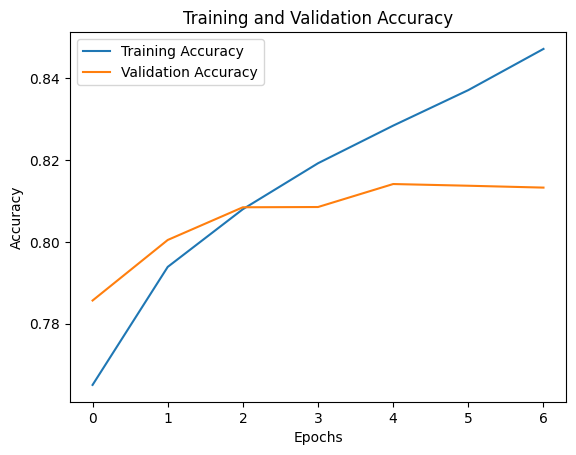

In [239]:
# plot accuracy on training and validation data
plt.plot(history_attention.history['accuracy'], label='Training Accuracy')
plt.plot(history_attention.history['val_accuracy'], label='Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.title('Training and Validation Accuracy')
plt.show()

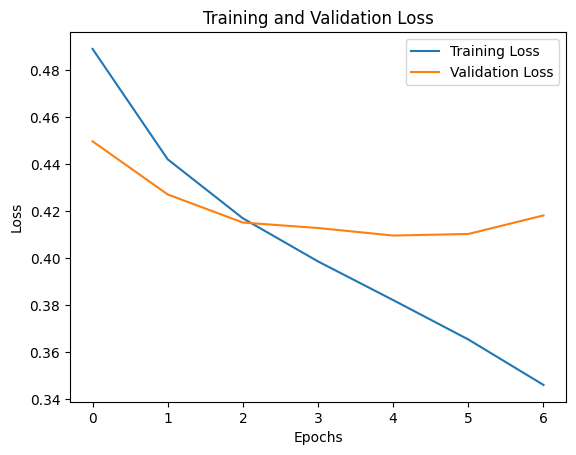

In [240]:
# plot loss on training and validation data
plt.plot(history_attention.history['loss'], label='Training Loss')
plt.plot(history_attention.history['val_loss'], label='Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.title('Training and Validation Loss')
plt.show()

In [241]:
# evaluate the model on the validation set
print("\nValidation Results:")
y_val_pred = (model_attention.predict(X_val) > 0.5).astype(int).flatten()
print(classification_report(y_val, y_val_pred))


Validation Results:
1501/1501 [==============================] - 8s 5ms/step
              precision    recall  f1-score   support

           0       0.79      0.85      0.82     24004
           1       0.84      0.77      0.81     24004

    accuracy                           0.81     48008
   macro avg       0.82      0.81      0.81     48008
weighted avg       0.82      0.81      0.81     48008



## 2.5. Model Evaluation on Test Data

In [242]:
train_lstm.evaluate_model(model=model_bilstm, tokenizer=tokenizer, test_df=test_sentiment140_df, max_length=max_length)

1500/1500 [==============================] - 7s 5ms/step

Classification Report for Test Set:

              precision    recall  f1-score   support

           0       0.80      0.84      0.82     24000
           1       0.83      0.79      0.81     24000

    accuracy                           0.82     48000
   macro avg       0.82      0.82      0.82     48000
weighted avg       0.82      0.82      0.82     48000



## 2.6. Model Evaluation on Augmented Data

In [243]:
# load the augmented test sets
test_sentiment140_char_swap_file = '../data/preprocessed/sentiment140_test_char_swap.csv'
test_sentiment140_char_swap_df = pd.read_csv(test_sentiment140_char_swap_file, engine='python', encoding="ISO-8859-1")

test_sentiment140_embedding_file = '../data/preprocessed/sentiment140_test_embedding.csv'
test_sentiment140_embedding_df = pd.read_csv(test_sentiment140_embedding_file, engine='python', encoding="ISO-8859-1")

test_sentiment140_eda_file = '../data/preprocessed/sentiment140_test_eda.csv'
test_sentiment140_eda_df = pd.read_csv(test_sentiment140_eda_file, engine='python', encoding="ISO-8859-1")

In [244]:
train_lstm.evaluate_model(model=model_bilstm, tokenizer=tokenizer, test_df=test_sentiment140_char_swap_df, max_length=max_length)

1500/1500 [==============================] - 8s 5ms/step

Classification Report for Test Set:

              precision    recall  f1-score   support

           0       0.79      0.80      0.79     24000
           1       0.80      0.78      0.79     24000

    accuracy                           0.79     48000
   macro avg       0.79      0.79      0.79     48000
weighted avg       0.79      0.79      0.79     48000



In [245]:
train_lstm.evaluate_model(model=model_bilstm, tokenizer=tokenizer, test_df=test_sentiment140_embedding_df, max_length=max_length)


1500/1500 [==============================] - 7s 5ms/step

Classification Report for Test Set:

              precision    recall  f1-score   support

           0       0.79      0.80      0.79     24000
           1       0.79      0.78      0.79     24000

    accuracy                           0.79     48000
   macro avg       0.79      0.79      0.79     48000
weighted avg       0.79      0.79      0.79     48000



In [246]:
train_lstm.evaluate_model(model=model_bilstm, tokenizer=tokenizer, test_df=test_sentiment140_eda_df, max_length=max_length)


1500/1500 [==============================] - 7s 5ms/step

Classification Report for Test Set:

              precision    recall  f1-score   support

           0       0.79      0.82      0.80     24000
           1       0.81      0.78      0.80     24000

    accuracy                           0.80     48000
   macro avg       0.80      0.80      0.80     48000
weighted avg       0.80      0.80      0.80     48000



## 2.7. Save Model

In [247]:
model_path = os.path.join(models_output_dir, "sentiment140_lstm_model.keras")
model_bilstm.save(model_path)

# 3. LSTM Model - Yelp Reviews

## 3.1. Loading Data

In [28]:
# load the dataset
yelp_file = '../data/preprocessed/yelp.csv'
yelp_df = pd.read_csv(yelp_file, engine='python', encoding="ISO-8859-1")

In [29]:
# preview the data
yelp_df.head()

,Polarity,Review
0,0,The food was pretty good but the server was so...
1,0,Horrible manager! She told us we only needed t...
2,1,I Love the Black Bean Burger. So much so I cam...
3,0,Off the beaten path and you can either park yo...
4,1,"Awesome NYC pizza, my second favorite NYC styl..."


In [30]:
train_val_yelp_df, test_yelp_df = train_test_split(
    yelp_df, 
    test_size=0.15, 
    random_state=42, 
    stratify=yelp_df['Polarity']
)

In [31]:
train_yelp_df, val_yelp_df = train_test_split(
    train_val_yelp_df, 
    test_size=0.1765, # 15% of the original data
    random_state=42, 
    stratify=train_val_yelp_df['Polarity']
)

In [32]:
DataUtils.count_reviews_by_polarity(train_yelp_df)

Number of reviews with Polarity=1: 39199
Number of reviews with Polarity=0: 39198


In [33]:
DataUtils.count_reviews_by_polarity(val_yelp_df)

Number of reviews with Polarity=1: 8401
Number of reviews with Polarity=0: 8402


In [34]:
DataUtils.count_reviews_by_polarity(test_yelp_df)

Number of reviews with Polarity=1: 8400
Number of reviews with Polarity=0: 8400


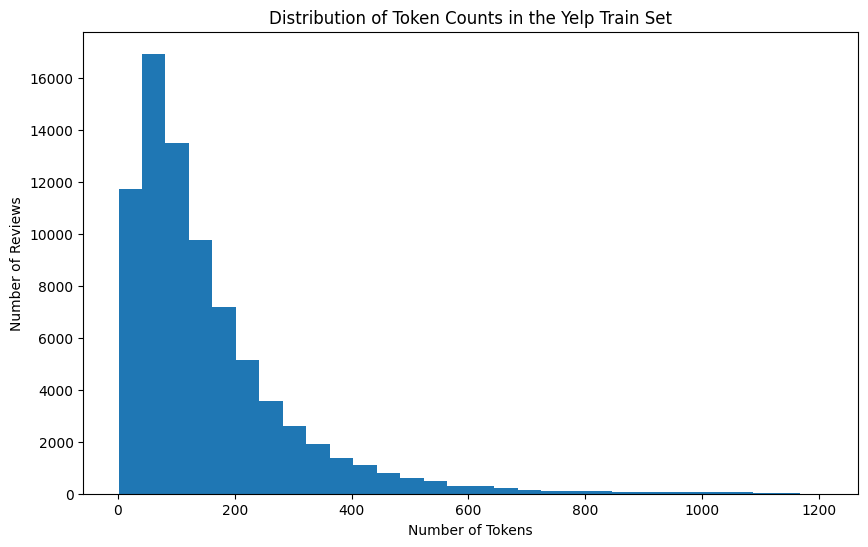

In [35]:
DataUtils.plot_token_distribution(train_yelp_df, "Yelp Train Set")

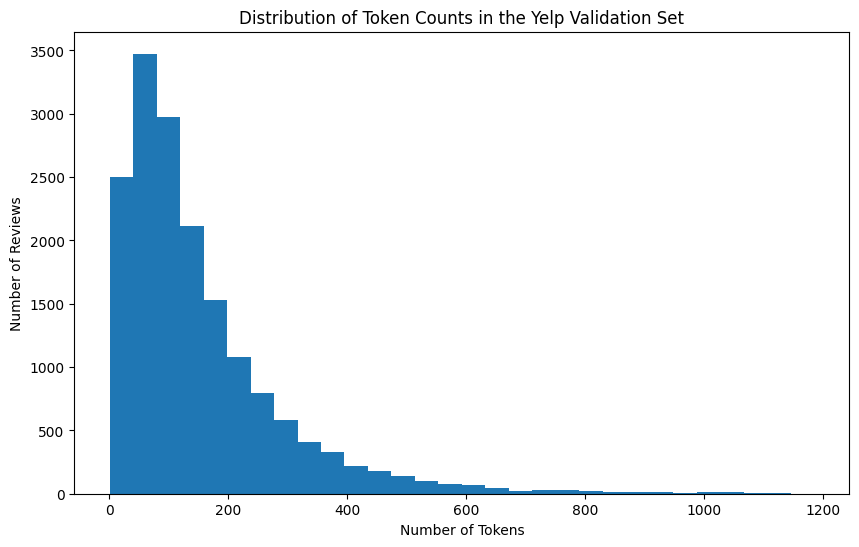

In [36]:
DataUtils.plot_token_distribution(val_yelp_df, "Yelp Validation Set")

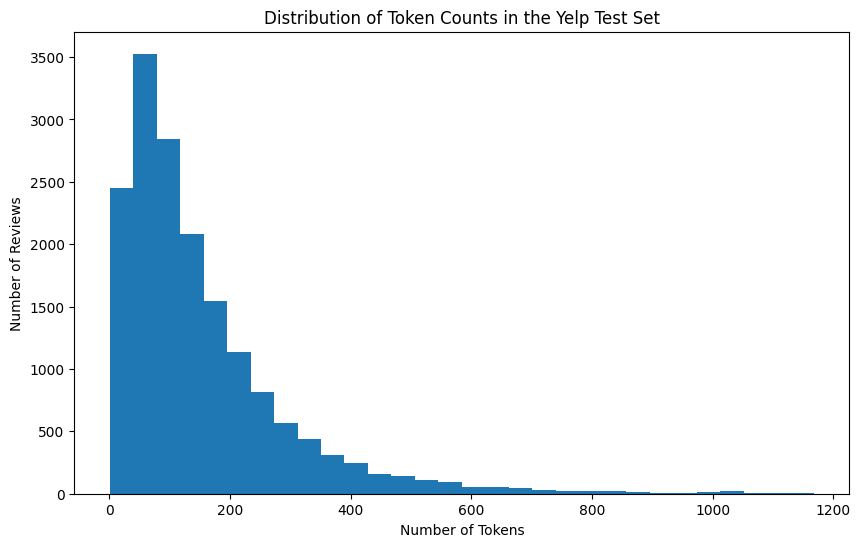

In [37]:
DataUtils.plot_token_distribution(test_yelp_df, "Yelp Test Set")

## 3.2. Data Preprocessing

In [100]:
# set preprocessing parameters
vocab_size = 15000  # maximum number of words in the tokenizer
max_length = 256  # maximum length of input sequences

In [101]:
# preprocess train data and fit tokenizer
X_train, y_train, tokenizer = preprocess_data(train_yelp_df, max_length=max_length, vocab_size=vocab_size)

In [102]:
# preprocess val data 
X_val, y_val = tokenize_with_existing_tokenizer(val_yelp_df, tokenizer, max_length)

In [103]:
# preprocess test data
X_test, y_test = tokenize_with_existing_tokenizer(test_yelp_df, tokenizer, max_length)

## 3.3. Model Training

In [104]:
# set model parameters
batch_size = 32
epochs = 10
learning_rate = 0.001

In [105]:
# set embedding parameters
embedding_dim = 300  # dimension of word vectors
embedding_matrix = np.zeros((vocab_size, embedding_dim)) 

for word, i in tokenizer.word_index.items():
    if i < vocab_size:  
        embedding_matrix[i] = fasttext_model.get_word_vector(word)  

print("Embedding matrix created with shape:", embedding_matrix.shape)

Embedding matrix created with shape: (10000, 300)


In [110]:
# define model architecture
model_lstm = Sequential([
    Embedding(input_dim=vocab_size, output_dim=embedding_dim, 
              input_length=max_length, weights=[embedding_matrix], 
              trainable=False),
    LSTM(256, return_sequences=True), 
    Dropout(0.3),
    LSTM(128, return_sequences=False),
    Dropout(0.3),
    Dense(64, activation='relu'), 
    Dropout(0.3),
    Dense(1, activation='sigmoid')  
])

In [111]:
model_lstm.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=learning_rate),
              loss='binary_crossentropy',
              metrics=['accuracy'])

In [112]:
# define callbacks
early_stopping = EarlyStopping(
    monitor='val_loss',
    patience=2,
    restore_best_weights=True
)

In [113]:
# train the model
history_lstm = model_lstm.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=epochs,
    batch_size=batch_size,
    callbacks=[early_stopping]
)

Epoch 1/10
2450/2450 [==============================] - 77s 31ms/step - loss: 0.6922 - accuracy: 0.5128 - val_loss: 0.6932 - val_accuracy: 0.5000
Epoch 2/10
2450/2450 [==============================] - 73s 30ms/step - loss: 0.6894 - accuracy: 0.5235 - val_loss: 0.6860 - val_accuracy: 0.5366
Epoch 3/10
2450/2450 [==============================] - 73s 30ms/step - loss: 0.6807 - accuracy: 0.5432 - val_loss: 0.6803 - val_accuracy: 0.5000
Epoch 4/10
2450/2450 [==============================] - 73s 30ms/step - loss: 0.5482 - accuracy: 0.6797 - val_loss: 0.2701 - val_accuracy: 0.8872
Epoch 5/10
2450/2450 [==============================] - 73s 30ms/step - loss: 0.2340 - accuracy: 0.9083 - val_loss: 0.2055 - val_accuracy: 0.9149
Epoch 6/10
2450/2450 [==============================] - 73s 30ms/step - loss: 0.1964 - accuracy: 0.9236 - val_loss: 0.1975 - val_accuracy: 0.9245
Epoch 7/10
2450/2450 [==============================] - 73s 30ms/step - loss: 0.1739 - accuracy: 0.9322 - val_loss: 0.1763 -

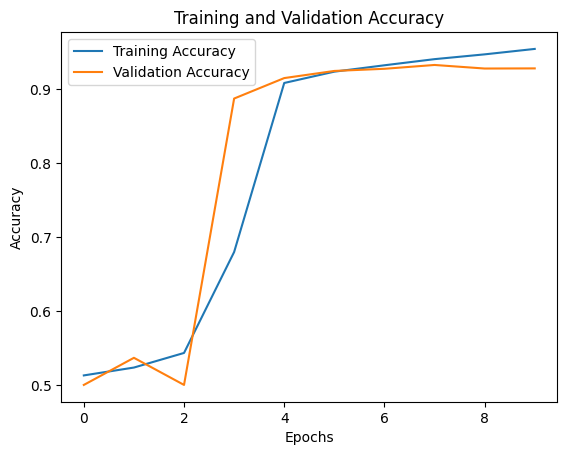

In [114]:
# plot accuracy on training and validation data
plt.plot(history_lstm.history['accuracy'], label='Training Accuracy')
plt.plot(history_lstm.history['val_accuracy'], label='Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.title('Training and Validation Accuracy')
plt.show()

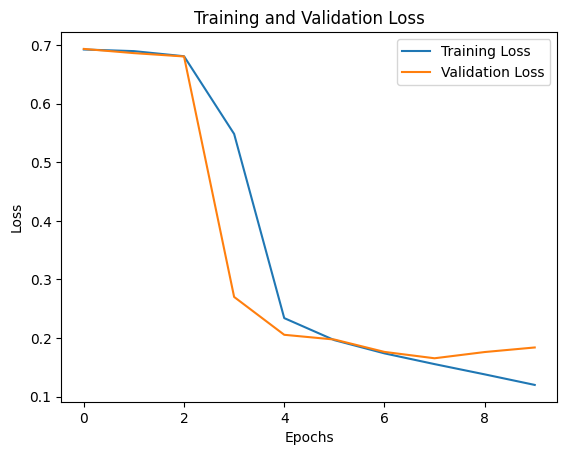

In [115]:
# plot loss on training and validation data
plt.plot(history_lstm.history['loss'], label='Training Loss')
plt.plot(history_lstm.history['val_loss'], label='Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.title('Training and Validation Loss')
plt.show()

In [116]:
# evaluate the model on the validation set
print("\nValidation Results:")
y_val_pred = (model_lstm.predict(X_val) > 0.5).astype(int).flatten()
print(classification_report(y_val, y_val_pred))


Validation Results:
526/526 [==============================] - 7s 13ms/step
              precision    recall  f1-score   support

           0       0.92      0.95      0.93      8402
           1       0.94      0.92      0.93      8401

    accuracy                           0.93     16803
   macro avg       0.93      0.93      0.93     16803
weighted avg       0.93      0.93      0.93     16803



## 3.4. Searching for Best Model Parameters

### 3.4.1. BiLSTM

In [132]:
model_bilstm = Sequential([
    Embedding(input_dim=vocab_size, output_dim=embedding_dim, 
              input_length=max_length, weights=[embedding_matrix], 
              trainable=False),
    Bidirectional(LSTM(256, return_sequences=True)),  
    Dropout(0.3),
    Bidirectional(LSTM(128, return_sequences=False)), 
    Dropout(0.3),
    Dense(64, activation='relu'), 
    Dropout(0.3),
    Dense(1, activation='sigmoid')  
])

In [133]:
model_bilstm.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=learning_rate),
              loss='binary_crossentropy',
              metrics=['accuracy'])

In [134]:
# train the model
history_bilstm = model_bilstm.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=epochs,
    batch_size=batch_size,
    callbacks=[early_stopping]
)

Epoch 1/10
2450/2450 [==============================] - 146s 58ms/step - loss: 0.5373 - accuracy: 0.7294 - val_loss: 0.3868 - val_accuracy: 0.8448
Epoch 2/10
2450/2450 [==============================] - 139s 57ms/step - loss: 0.2631 - accuracy: 0.8935 - val_loss: 0.2214 - val_accuracy: 0.9075
Epoch 3/10
2450/2450 [==============================] - 139s 57ms/step - loss: 0.2037 - accuracy: 0.9192 - val_loss: 0.1874 - val_accuracy: 0.9229
Epoch 4/10
2450/2450 [==============================] - 139s 57ms/step - loss: 0.1781 - accuracy: 0.9299 - val_loss: 0.1714 - val_accuracy: 0.9301
Epoch 5/10
2450/2450 [==============================] - 139s 57ms/step - loss: 0.1608 - accuracy: 0.9372 - val_loss: 0.1606 - val_accuracy: 0.9336
Epoch 6/10
2450/2450 [==============================] - 139s 57ms/step - loss: 0.1424 - accuracy: 0.9454 - val_loss: 0.1578 - val_accuracy: 0.9352
Epoch 7/10
2450/2450 [==============================] - 139s 57ms/step - loss: 0.1279 - accuracy: 0.9506 - val_loss: 0

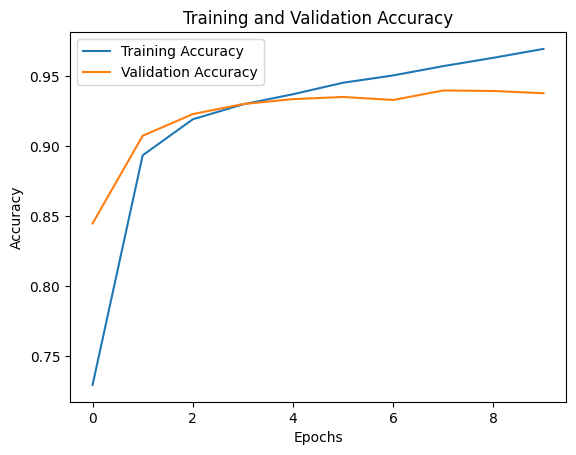

In [135]:
# plot accuracy on training and validation data
plt.plot(history_bilstm.history['accuracy'], label='Training Accuracy')
plt.plot(history_bilstm.history['val_accuracy'], label='Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.title('Training and Validation Accuracy')
plt.show()

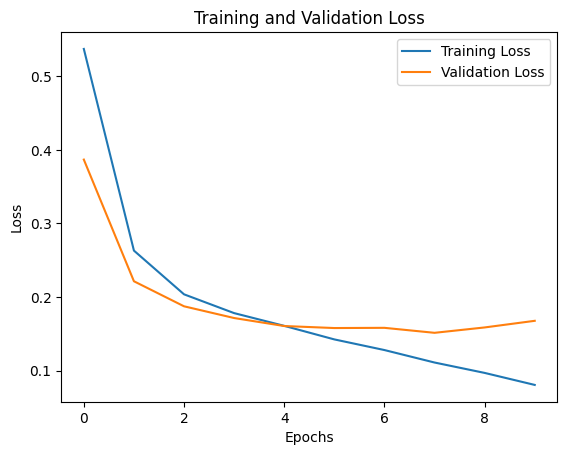

In [136]:
# plot loss on training and validation data
plt.plot(history_bilstm.history['loss'], label='Training Loss')
plt.plot(history_bilstm.history['val_loss'], label='Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.title('Training and Validation Loss')
plt.show()

In [137]:
# evaluate the model on the validation set
print("\nValidation Results:")
y_val_pred = (model_bilstm.predict(X_val) > 0.5).astype(int).flatten()
print(classification_report(y_val, y_val_pred))


Validation Results:
526/526 [==============================] - 14s 24ms/step
              precision    recall  f1-score   support

           0       0.93      0.95      0.94      8402
           1       0.95      0.93      0.94      8401

    accuracy                           0.94     16803
   macro avg       0.94      0.94      0.94     16803
weighted avg       0.94      0.94      0.94     16803



### 3.4.2. BiLSTM + Attention

In [ ]:
def build_attention_lstm_model_yelp(vocab_size, embedding_dim, max_length, embedding_matrix, learning_rate=0.001):
    # define inputs
    inputs = Input(shape=(max_length,))
    
    # embedding layer
    embedding = Embedding(input_dim=vocab_size, output_dim=embedding_dim, 
                          input_length=max_length, weights=[embedding_matrix], 
                          trainable=False)(inputs)

    # BiLSTM layers
    lstm_output = Bidirectional(LSTM(256, return_sequences=True))(embedding)  
    lstm_output = Bidirectional(LSTM(128, return_sequences=True))(lstm_output)
    
    # attention layer
    attention_output = attention_layer(lstm_output)

    # fully connected layers
    dropout1 = Dropout(0.3)(attention_output)
    dense1 = Dense(128, activation='relu')(dropout1)  
    dropout2 = Dropout(0.3)(dense1)
    dense2 = Dense(64, activation='relu')(dropout2)
    dropout3 = Dropout(0.3)(dense2)
    outputs = Dense(1, activation='sigmoid')(dropout3)

    # define the model
    model = Model(inputs=inputs, outputs=outputs)

    # compile the model
    model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=learning_rate), 
                  loss='binary_crossentropy', metrics=['accuracy'])

    return model

In [138]:
model_attention = build_attention_lstm_model_yelp(vocab_size=vocab_size, embedding_dim=embedding_dim, max_length=max_length, embedding_matrix=embedding_matrix, learning_rate=learning_rate)

In [139]:
# train the model
history_attention = model_attention.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=epochs,
    batch_size=batch_size,
    callbacks=[early_stopping]
)

Epoch 1/10
2450/2450 [==============================] - 155s 61ms/step - loss: 0.3329 - accuracy: 0.8466 - val_loss: 0.2200 - val_accuracy: 0.9131
Epoch 2/10
2450/2450 [==============================] - 149s 61ms/step - loss: 0.2009 - accuracy: 0.9206 - val_loss: 0.1814 - val_accuracy: 0.9253
Epoch 3/10
2450/2450 [==============================] - 145s 59ms/step - loss: 0.1712 - accuracy: 0.9334 - val_loss: 0.1659 - val_accuracy: 0.9322
Epoch 4/10
2450/2450 [==============================] - 140s 57ms/step - loss: 0.1487 - accuracy: 0.9419 - val_loss: 0.1613 - val_accuracy: 0.9329
Epoch 5/10
2450/2450 [==============================] - 141s 58ms/step - loss: 0.1302 - accuracy: 0.9508 - val_loss: 0.1695 - val_accuracy: 0.9350
Epoch 6/10
2450/2450 [==============================] - 147s 60ms/step - loss: 0.1092 - accuracy: 0.9590 - val_loss: 0.1810 - val_accuracy: 0.9327


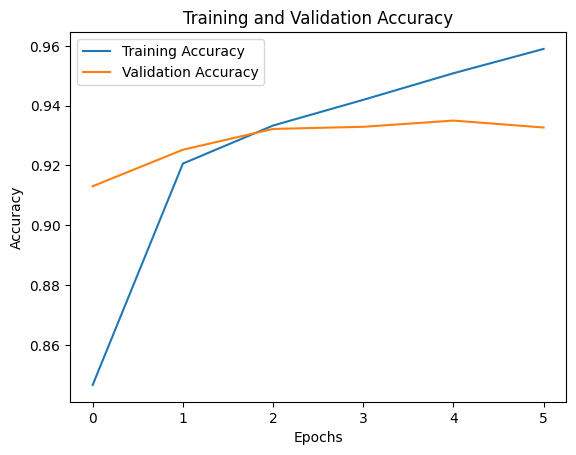

In [140]:
# plot accuracy on training and validation data
plt.plot(history_attention.history['accuracy'], label='Training Accuracy')
plt.plot(history_attention.history['val_accuracy'], label='Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.title('Training and Validation Accuracy')
plt.show()

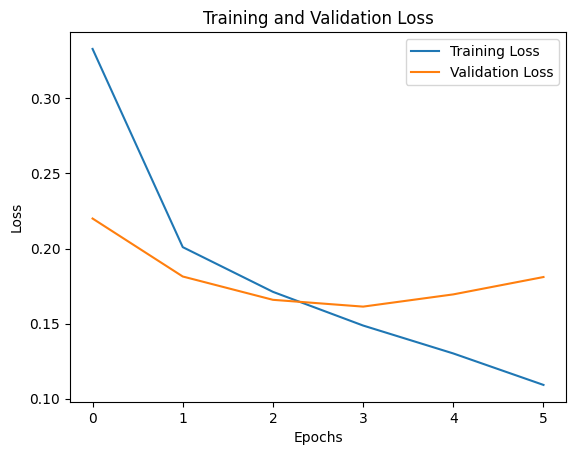

In [141]:
# plot loss on training and validation data
plt.plot(history_attention.history['loss'], label='Training Loss')
plt.plot(history_attention.history['val_loss'], label='Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.title('Training and Validation Loss')
plt.show()

In [142]:
# evaluate the model on the validation set
print("\nValidation Results:")
y_val_pred = (model_attention.predict(X_val) > 0.5).astype(int).flatten()
print(classification_report(y_val, y_val_pred))


Validation Results:
526/526 [==============================] - 15s 27ms/step
              precision    recall  f1-score   support

           0       0.95      0.92      0.93      8402
           1       0.92      0.95      0.93      8401

    accuracy                           0.93     16803
   macro avg       0.93      0.93      0.93     16803
weighted avg       0.93      0.93      0.93     16803



## 3.5. Model Evaluation on Test Data

In [144]:
train_lstm.evaluate_model(model=model_attention, tokenizer=tokenizer, test_df=test_yelp_df, max_length=max_length)

525/525 [==============================] - 14s 27ms/step

Classification Report for Test Set:

              precision    recall  f1-score   support

           0       0.95      0.92      0.93      8400
           1       0.92      0.95      0.94      8400

    accuracy                           0.94     16800
   macro avg       0.94      0.94      0.94     16800
weighted avg       0.94      0.94      0.94     16800



## 3.6. Model Evaluation on Augmented Data

In [145]:
# load the augmented test sets
test_yelp_char_swap_file = '../data/preprocessed/yelp_test_char_swap.csv'
test_yelp_char_swap_df = pd.read_csv(test_yelp_char_swap_file, engine='python', encoding="ISO-8859-1")

test_yelp_transform_file = '../data/preprocessed/yelp_test_transform.csv'
test_yelp_transform_df = pd.read_csv(test_yelp_transform_file, engine='python', encoding="ISO-8859-1")

test_yelp_combined_file = '../data/preprocessed/yelp_test_combined.csv'
test_yelp_combined_df = pd.read_csv(test_yelp_combined_file, engine='python', encoding="ISO-8859-1")

In [146]:
train_lstm.evaluate_model(model=model_attention, tokenizer=tokenizer, test_df=test_yelp_char_swap_df, max_length=max_length)

525/525 [==============================] - 13s 24ms/step

Classification Report for Test Set:

              precision    recall  f1-score   support

           0       0.89      0.78      0.84      8400
           1       0.81      0.91      0.85      8400

    accuracy                           0.85     16800
   macro avg       0.85      0.85      0.84     16800
weighted avg       0.85      0.85      0.84     16800



In [147]:
train_lstm.evaluate_model(model=model_attention, tokenizer=tokenizer, test_df=test_yelp_transform_df, max_length=max_length)


525/525 [==============================] - 13s 25ms/step

Classification Report for Test Set:

              precision    recall  f1-score   support

           0       0.93      0.90      0.91      8400
           1       0.90      0.93      0.92      8400

    accuracy                           0.91     16800
   macro avg       0.91      0.91      0.91     16800
weighted avg       0.91      0.91      0.91     16800



In [148]:
train_lstm.evaluate_model(model=model_attention, tokenizer=tokenizer, test_df=test_yelp_combined_df, max_length=max_length)


525/525 [==============================] - 14s 27ms/step

Classification Report for Test Set:

              precision    recall  f1-score   support

           0       0.87      0.76      0.81      8400
           1       0.78      0.89      0.83      8400

    accuracy                           0.82     16800
   macro avg       0.83      0.82      0.82     16800
weighted avg       0.83      0.82      0.82     16800



## 3.7. Save Model

In [149]:
model_path = os.path.join(models_output_dir, "yelp_lstm_model.keras")
model_attention.save(model_path)